# Is a Synthetic Image Worth a Real One?

Generative data augmentation on OxfordIIITPet, measured against the real images
it is meant to replace.

The pipeline follows the brief: caption the real images with BLIP, rewrite the
captions with flan-t5, generate new images with SD-Turbo, then train a classifier
on the reduced dataset and on the augmented one.

Four training setups, all sharing the same architecture, hyperparameters, seeds
and test set:

1. **baseline** — 400 real images
2. **ceiling** — all 995 real images available, the reference for what real data
   is worth
3. **classic augmentation** — the same 400 images, randomly transformed
4. **generative augmentation** — the 400 images plus 595 generated ones

Setups 2 and 3 are not asked for in the brief. Without the ceiling there is no
way to tell whether a gain is large or small, and without classic augmentation no
way to tell whether the generative pipeline beats a horizontal flip.

Two checks sit outside the brief as well: the generated images are scored by an
external judge before being used, and every setup is re-evaluated on a blurred
test set, which is the condition the surveillance use case actually runs in.

In [ ]:
import random
from collections import defaultdict
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor

# dataset and classifier
from torchvision.datasets import OxfordIIITPet, ImageFolder
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

# classification metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# generative pipeline: captioning -> text variants -> image generation
from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
)
from diffusers import AutoPipelineForText2Image

# keep the output readable: library deprecation notices are not relevant here
import warnings
warnings.filterwarnings("ignore")


SEED = 0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


## 1. Downloading and Analysing Dataset

We subsample OxfordIIITPet to reproduce the data scarcity described in the use
case:

- 10 breeds out of 37, 40 images per class in training
- the random draw gave 8 dog breeds and 2 cat breeds, classes stay balanced
- the test set is real images only, all the ones available for the 10 breeds

It will be interesting to look at the effect of augmentation class by class, in
particular on the two cat breeds.

In [ ]:
trainval = OxfordIIITPet(root="./data", split="trainval", download=True)
test = OxfordIIITPet(root="./data", split="test", download=True)

print("trainval images:", len(trainval))
print("test images:", len(test))
print("number of breeds:", len(trainval.classes))
print("first 10 breeds:", trainval.classes[:10])

trainval images: 3680
test images: 3669
number of breeds: 37
first 10 breeds: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair']


In [ ]:
N_CLASSES = 10

random.seed(SEED)  # reseed here, so re-running this cell gives the same breeds

selected_classes = sorted(random.sample(range(len(trainval.classes)), N_CLASSES))
class_names = [trainval.classes[c] for c in selected_classes]

for original_label, name in zip(selected_classes, class_names):
    print(original_label, name)

2 American Pit Bull Terrier
12 English Cocker Spaniel
16 Havanese
24 Pomeranian
25 Pug
26 Ragdoll
29 Samoyed
31 Shiba Inu
32 Siamese
35 Wheaten Terrier


In [ ]:
# mapping selected labels from 0 to 9
label_map = {original: new for new, original in enumerate(selected_classes)}

def remap_label(label):
    return label_map[label]

print(label_map)

{2: 0, 12: 1, 16: 2, 24: 3, 25: 4, 26: 5, 29: 6, 31: 7, 32: 8, 35: 9}


In [ ]:
# the pretrained ResNet expects ImageNet normalization
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# same crop as eval_transform but without normalization: CLIP and FID
# both apply their own preprocessing downstream
raw_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

In [ ]:
# rebuild the datasets with transform and label remapping set at construction,
# so the cells below do not depend on any later assignment
trainval = OxfordIIITPet(root="./data", split="trainval",
                         transform=eval_transform, target_transform=remap_label)
test = OxfordIIITPet(root="./data", split="test",
                     transform=eval_transform, target_transform=remap_label)

print(f"{'trainval:':<12}{len(trainval):>6}")
print(f"{'test:':<12}{len(test):>6}")

trainval:     3680
test:         3669


In [ ]:
# _labels holds the original labels, so grouping still works after the remapping
indices_by_class = defaultdict(list)
for index, label in enumerate(trainval._labels):
    if label in label_map:
        indices_by_class[label].append(index)

print({label: len(indices) for label, indices in indices_by_class.items()})

{2: 100, 12: 96, 16: 100, 24: 100, 25: 100, 26: 100, 29: 100, 31: 100, 32: 99, 35: 100}


## 2. Splits

`train_small` is the scarce-data regime, 40 images per class. `train_full` is
the ceiling, with every real image available. The test set is real images only
and is shared by all setups.

In [ ]:
# split the reduced training pool from the rest, class by class
N_TRAIN_PER_CLASS = 40

rng = random.Random(SEED)  # local generator: the cell is reproducible on its own

small_indices, remaining_indices = [], []
for indices in indices_by_class.values():
    shuffled = rng.sample(indices, len(indices))
    small_indices += shuffled[:N_TRAIN_PER_CLASS]
    remaining_indices += shuffled[N_TRAIN_PER_CLASS:]

test_indices = [i for i, label in enumerate(test._labels) if label in label_map]

print(f"{'small train:':<16}{len(small_indices):>6}")
print(f"{'remaining:':<16}{len(remaining_indices):>6}")
print(f"{'test:':<16}{len(test_indices):>6}")

small train:       400
remaining:         595
test:             1000


In [ ]:
train_small = Subset(trainval, small_indices)
train_full = Subset(trainval, small_indices + remaining_indices)
test_set = Subset(test, test_indices)

image, label = train_small[0]
print(f"{'image shape:':<16}{tuple(image.shape)}")
print(f"{'label:':<16}{label:<4}{class_names[label]}")
print(f"{'train_full:':<16}{len(train_full)}")

image shape:    (3, 224, 224)
label:          0   American Pit Bull Terrier
train_full:     995


In [ ]:
# test labels, in the same order predict() returns them (the loader does not shuffle)
y_true = np.array([remap_label(test._labels[i]) for i in test_indices])
print(f"{'test labels:':<16}{len(y_true):>6}")

test labels:      1000


## 3. Helpers

The four setups differ only in the training set. Everything they share is
defined once here:

- model construction, training loop and prediction
- metrics, confusion matrix and checkpoint saving

In [ ]:
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

print(f"{'checkpoints in:':<18}{CHECKPOINT_DIR.resolve()}")

checkpoints in:   /content/checkpoints


In [ ]:
def build_model(n_classes, seed):
    """ResNet18 trained from scratch: no pretrained weights, all layers trainable."""
    torch.manual_seed(seed)  # same initialization in every setup
    model = resnet18(weights=None, num_classes=n_classes)
    return model.to(DEVICE)

In [ ]:
def train_model(model, dataset, epochs, batch_size, lr, seed, progress=None):
    """Train the model and return it together with the per-epoch mean loss."""
    generator = torch.Generator().manual_seed(seed)  # fixed batch order
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                        num_workers=0, generator=generator)
    criterion = nn.CrossEntropyLoss()  # expects raw logits
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0) # .item() detaches the graph
        loss_history.append(running_loss / len(dataset))

        # live feedback on the seed bar: epoch and current loss
        if progress is not None:
            progress.set_postfix(epoch=f"{epoch + 1}/{epochs}",
                                 loss=f"{loss_history[-1]:.3f}")

    return model, loss_history

In [ ]:
@torch.no_grad()
def predict(model, dataset, batch_size=64):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()

    all_predictions, all_labels = [], []
    for images, labels in loader:
        logits = model(images.to(DEVICE))
        all_predictions.append(logits.argmax(dim=1).cpu())
        all_labels.append(labels)
    return torch.cat(all_labels).numpy(), torch.cat(all_predictions).numpy()

In [ ]:
def compute_metrics(y_true, y_pred):
    """Macro-averaged metrics: all classes weigh the same, as they are balanced."""
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [ ]:
SEEDS = [0, 1, 2, 3, 4]

def run_setup(name, dataset, epochs, batch_size, lr, test_set, y_true):
    """Train the same setup on every seed, saving each model for later re-evaluation."""
    runs, predictions, curves = [], [], []
    progress = tqdm(SEEDS, desc=name)
    for seed in progress:
        model = build_model(N_CLASSES, seed)
        model, losses = train_model(model, dataset, epochs, batch_size, lr, seed, progress)
        torch.save(model.state_dict(),
                   CHECKPOINT_DIR / f"{name.replace(' ', '_')}_seed{seed}.pt")
        _, y_pred = predict(model, test_set)
        runs.append(compute_metrics(y_true, y_pred))
        predictions.append(y_pred)
        curves.append(losses)
    return runs, predictions, curves

In [ ]:
def print_runs(name, runs):
    print(f"--- {name} ---")
    for metric_name in runs[0]:
        values = np.array([run[metric_name] for run in runs])
        print(f"{metric_name:<12}{values.mean():>8.3f}  ± {values.std():>5.3f}")

In [ ]:
def plot_confusion_matrix(matrix, title):
    display = ConfusionMatrixDisplay(matrix, display_labels=class_names)

    figure, axes = plt.subplots(figsize=(8, 8))
    display.plot(ax=axes, cmap="Blues", colorbar=False, xticks_rotation=90,
                 values_format=".2f")
    axes.set_title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
def mean_confusion_matrix(predictions):
    """Row-normalised confusion matrix averaged over the seeds."""
    matrices = [confusion_matrix(y_true, y_pred, normalize="true")
                for y_pred in predictions]
    return np.mean(matrices, axis=0)

## 4. Baseline and Ceiling

The two references every other setup is compared against: 400 real images with
no augmentation, and all 995 real images available for the 10 breeds.

The classifier is trained from scratch:

- with ImageNet weights the baseline reached 94% accuracy even at 10 images per
  class, the breeds are covered by ImageNet
- without pretraining the accuracy is lower, but the size of the training set
  becomes the variable that actually drives performance

Hyperparameters are fixed here and reused unchanged in the four scratch setups.

In [ ]:
# fixed once, reused unchanged in all four setups
EPOCHS = 30
BATCH_SIZE = 32
LR = 1e-3

print(f"{'epochs:':<14}{EPOCHS:>6}")
print(f"{'batch size:':<14}{BATCH_SIZE:>6}")
print(f"{'learning rate:':<14}{LR:>6}")

epochs:           30
batch size:       32
learning rate: 0.001


In [ ]:
runs_baseline, predictions_baseline, curves_baseline = run_setup(
    "baseline", train_small, EPOCHS, BATCH_SIZE, LR, test_set, y_true
)
print_runs("1 - baseline (400 real)", runs_baseline)

baseline:   0%|          | 0/5 [00:00<?, ?it/s]

--- 1 - baseline (400 real) ---
accuracy       0.304  ± 0.010
precision      0.339  ± 0.021
recall         0.304  ± 0.010
f1             0.295  ± 0.014


Now the ceiling: all 995 real images, to see what real data is worth compared to
augmentation.

In [ ]:
runs_ceiling, predictions_ceiling, curves_ceiling = run_setup(
    "ceiling", train_full, EPOCHS, BATCH_SIZE, LR, test_set, y_true
)
print_runs("2 - ceiling (995 real)", runs_ceiling)

ceiling:   0%|          | 0/5 [00:00<?, ?it/s]

--- 2 - ceiling (995 real) ---
accuracy       0.409  ± 0.018
precision      0.456  ± 0.035
recall         0.409  ± 0.018
f1             0.401  ± 0.025


- Baseline 30.4% ±0.010 against ceiling 40.9% ±0.018: a 10-point gap, several
  times the run-to-run spread, so there is room to measure an augmentation effect
- The limiting factor is the amount of data, not the architecture

## 5. Classic Augmentation
Same 400 real images, seen through random transformations at every epoch:

- random resized crop and horizontal flip, to vary framing and pose
- colour jitter, to vary lighting


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
# second instance of the dataset: same images and indices, different transform
trainval_augmented = OxfordIIITPet(root="./data", split="trainval",
                                   transform=train_transform,
                                   target_transform=remap_label)

train_small_augmented = Subset(trainval_augmented, small_indices)
print(f"{'augmented train:':<18}{len(train_small_augmented):>6}")

augmented train:     400


In [ ]:
runs_classic, predictions_classic, curves_classic = run_setup(
    "classic aug", train_small_augmented, EPOCHS, BATCH_SIZE, LR, test_set, y_true
)
print_runs("3 - classic augmentation (400 real)", runs_classic)

classic aug:   0%|          | 0/5 [00:00<?, ?it/s]

--- 3 - classic augmentation (400 real) ---
accuracy       0.290  ± 0.016
precision      0.337  ± 0.028
recall         0.290  ± 0.016
f1             0.272  ± 0.019


Classic augmentation does not help here: 29.0% ±0.016 against 30.4% ±0.010 for
the baseline, a small but consistent drop.

The final training loss explains why: 1.09 against 0.22 for the baseline. With
the transforms active the network is still far from fitting its training set
after 30 epochs, so the epoch budget is the binding constraint rather than the
augmentation itself.

## 6. Image Captioning

BLIP describes each of the 400 training images. It captions the scene, not the
breed: "a white dog sitting on the grass".

That is why the breed name is added later from the label.
BLIP contributes the background, the pose and the lighting, which is the variability we want in the generated images.

In [ ]:
CAPTION_MODEL = "Salesforce/blip-image-captioning-base"

blip_processor = BlipProcessor.from_pretrained(CAPTION_MODEL)
blip_model = BlipForConditionalGeneration.from_pretrained(
    CAPTION_MODEL, torch_dtype=torch.float16
).to(DEVICE)

print(f"{'caption model:':<16}{CAPTION_MODEL}")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

caption model:  Salesforce/blip-image-captioning-base


In [ ]:
# BLIP has its own processor: it needs the raw PIL images, not the normalized tensors
trainval_raw = OxfordIIITPet(root="./data", split="trainval", target_transform=remap_label)

image, label = trainval_raw[small_indices[0]]
print(f"{'type:':<12}{type(image).__name__}")
print(f"{'size:':<12}{image.size}")
print(f"{'label:':<12}{class_names[label]}")

type:       Image
size:       (300, 225)
label:      American Pit Bull Terrier


In [ ]:
# check the output on a few images before running over the whole training set
for index in small_indices[:3]:
    image, label = trainval_raw[index]
    inputs = blip_processor(image, return_tensors="pt").to(DEVICE, torch.float16)
    output = blip_model.generate(**inputs, max_new_tokens=30)
    caption = blip_processor.decode(output[0], skip_special_tokens=True)
    print(f"{class_names[label]:<28}{caption}")

American Pit Bull Terrier   a dog sitting in a wooden bucket
American Pit Bull Terrier   a dog standing next to a person on a rug
American Pit Bull Terrier   a dog laying on a bed with a red collar


In [ ]:
def caption_image(image):
    inputs = blip_processor(image, return_tensors="pt").to(DEVICE, torch.float16)
    output = blip_model.generate(**inputs, max_new_tokens=30)
    return blip_processor.decode(output[0], skip_special_tokens=True)


captions = []  # aligned with small_indices
labels_small = []

for index in tqdm(small_indices, desc="captioning"):
    image, label = trainval_raw[index]
    captions.append(caption_image(image))
    labels_small.append(label)

print(f"{'captions:':<12}{len(captions)}")

captioning:   0%|          | 0/400 [00:00<?, ?it/s]

captions:   400


In [ ]:
# most frequent captions: BLIP tends to repeat generic descriptions
for caption, count in Counter(captions).most_common(5):
    print(f"{count:<4}{caption}")

print(f"\n{'unique captions:':<20}{len(set(captions)):>6}")

9   a cat with blue eyes
6   a dog laying on the floor
6   a dog laying on the ground
5   a dog laying in the grass
5   a cat laying on the floor

unique captions:       298


In [ ]:
# how many images the ceiling has on top of the baseline, class by class
synthetic_per_class = Counter(remap_label(trainval._labels[i]) for i in remaining_indices)

for label in range(N_CLASSES):
    print(f"{class_names[label]:<28}{synthetic_per_class[label]:>4}")
print(f"\n{'total:':<28}{sum(synthetic_per_class.values()):>4}")

American Pit Bull Terrier     60
English Cocker Spaniel        56
Havanese                      60
Pomeranian                    60
Pug                           60
Ragdoll                       60
Samoyed                       60
Shiba Inu                     60
Siamese                       59
Wheaten Terrier               60

total:                       595


## 7. Text Variants

flan-t5-base rewrites each caption into two alternative descriptions. 298 of the
400 captions are already unique, so the point is mostly volume: two variants per
image give enough distinct prompts to cover the 595 images we need.

595 is  exactly how many real images the ceiling has
on top of the baseline, class by class, so the generative setup and the ceiling
end up with the same image number and class distribution.

In [ ]:
TEXT_MODEL = "google/flan-t5-base"

t5_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(TEXT_MODEL).to(DEVICE)

print(f"{'text model:':<16}{TEXT_MODEL}")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

text model:     google/flan-t5-base


In [ ]:
# T5 is instruction-tuned: the task goes in the prompt as a prefix
VARIANTS_PER_CAPTION = 2

def generate_variants(caption):
    prompt = f"Rewrite this image description in a different way: {caption}"
    inputs = t5_tokenizer(prompt, return_tensors="pt").to(DEVICE)
    outputs = t5_model.generate(
        **inputs,
        max_new_tokens=40,
        do_sample=True,            # sampling, otherwise both variants are identical
        temperature=1.0,
        num_return_sequences=VARIANTS_PER_CAPTION,
    )
    return t5_tokenizer.batch_decode(outputs, skip_special_tokens=True)


print(f"original: {captions[0]}")
for variant in generate_variants(captions[0]):
    print(f"variant:  {variant}")

original: a dog sitting in a wooden bucket
variant:  wooden bucket surrounded by white dogs
variant:  A dog is playing in the ground after getting hurt when jumping from his bottle.


In [ ]:
variants_by_label = defaultdict(list)  # label -> list of caption variants

for caption, label in tqdm(zip(captions, labels_small), total=len(captions), desc="variants"):
    variants_by_label[label] += generate_variants(caption)

print(f"{'variants per class:':<22}{len(variants_by_label[0])}")
print(f"{'total variants:':<22}{sum(len(v) for v in variants_by_label.values())}")

variants:   0%|          | 0/400 [00:00<?, ?it/s]

variants per class:   80
total variants:       800


In [ ]:
# the breed name is mandatory: without it the synthetic images would be mislabelled
rng_prompts = random.Random(SEED)

prompts_by_label = {}
for label, variants in variants_by_label.items():
    selected = rng_prompts.sample(variants, synthetic_per_class[label])
    prompts_by_label[label] = [f"a photo of a {class_names[label]}, {v}" for v in selected]

print(f"{'total prompts:':<18}{sum(len(p) for p in prompts_by_label.values()):>6}")
print()
for prompt in prompts_by_label[0][:3]:
    print(prompt)

total prompts:       595

a photo of a American Pit Bull Terrier, A small dog standing in the dirt outside
a photo of a American Pit Bull Terrier, A black dog with a leash and a leash on it 's neck.
a photo of a American Pit Bull Terrier, A dog is laying on a bed with a red collar.


## 8. Image Generation

SD-Turbo generates one image per prompt, 595 in total. It is a distilled version
of Stable Diffusion: it produces an image in a single denoising step instead of
the usual 30, which is what makes this feasible on a Colab GPU.

Some T5 variants are degenerate ("read the collar on a dog for coat"), but the
breed prefix keeps the label correct regardless of what follows.

In [ ]:
IMAGE_MODEL = "stabilityai/sd-turbo"

sd_pipeline = AutoPipelineForText2Image.from_pretrained(
    IMAGE_MODEL, torch_dtype=torch.float16, variant="fp16"
).to(DEVICE)
sd_pipeline.set_progress_bar_config(disable=True)  # one bar for the whole loop instead

print(f"{'image model:':<16}{IMAGE_MODEL}")

model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


image model:    stabilityai/sd-turbo


a photo of a American Pit Bull Terrier, A small dog standing in the dirt outside


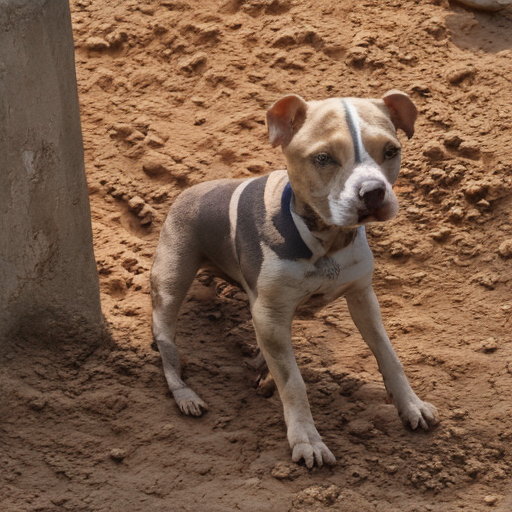

In [ ]:
# sd-turbo is distilled: 1 step, and guidance must be disabled
generator = torch.Generator(device=DEVICE).manual_seed(SEED)
preview = sd_pipeline(
    prompt=prompts_by_label[0][0],
    num_inference_steps=1,
    guidance_scale=0.0,
    generator=generator,
).images[0]

print(prompts_by_label[0][0])
preview

In [ ]:
SYNTHETIC_DIR = Path("synthetic")

for label in range(N_CLASSES):
    (SYNTHETIC_DIR / class_names[label]).mkdir(parents=True, exist_ok=True)

generator = torch.Generator(device=DEVICE).manual_seed(SEED)

for label in range(N_CLASSES):
    for i, prompt in enumerate(tqdm(prompts_by_label[label], desc=class_names[label])):
        image = sd_pipeline(
            prompt=prompt,
            num_inference_steps=1,
            guidance_scale=0.0,
            generator=generator,
        ).images[0]
        image.save(SYNTHETIC_DIR / class_names[label] / f"{i:03d}.png")

print(f"{'images saved in:':<18}{SYNTHETIC_DIR}")

American Pit Bull Terrier:   0%|          | 0/60 [00:00<?, ?it/s]

English Cocker Spaniel:   0%|          | 0/56 [00:00<?, ?it/s]

Havanese:   0%|          | 0/60 [00:00<?, ?it/s]

Pomeranian:   0%|          | 0/60 [00:00<?, ?it/s]

Pug:   0%|          | 0/60 [00:00<?, ?it/s]

...

Samoyed:   0%|          | 0/60 [00:00<?, ?it/s]

Shiba Inu:   0%|          | 0/60 [00:00<?, ?it/s]

Siamese:   0%|          | 0/59 [00:00<?, ?it/s]

Wheaten Terrier:   0%|          | 0/60 [00:00<?, ?it/s]

images saved in:  synthetic


## 9. Synthetic Quality Check

Before using the generated images to train a classifier, we check that the breed
is actually recognisable in them. Judging this by eye is not reliable, so CLIP is
used as an external zero-shot judge.

In [ ]:
# real training images grouped by remapped label, for the side-by-side preview
small_by_label = defaultdict(list)
for index, label in zip(small_indices, labels_small):
    small_by_label[label].append(index)

print(f"{'classes:':<14}{len(small_by_label):>6}")
print(f"{'per class:':<14}{len(small_by_label[0]):>6}")

classes:          10
per class:        40


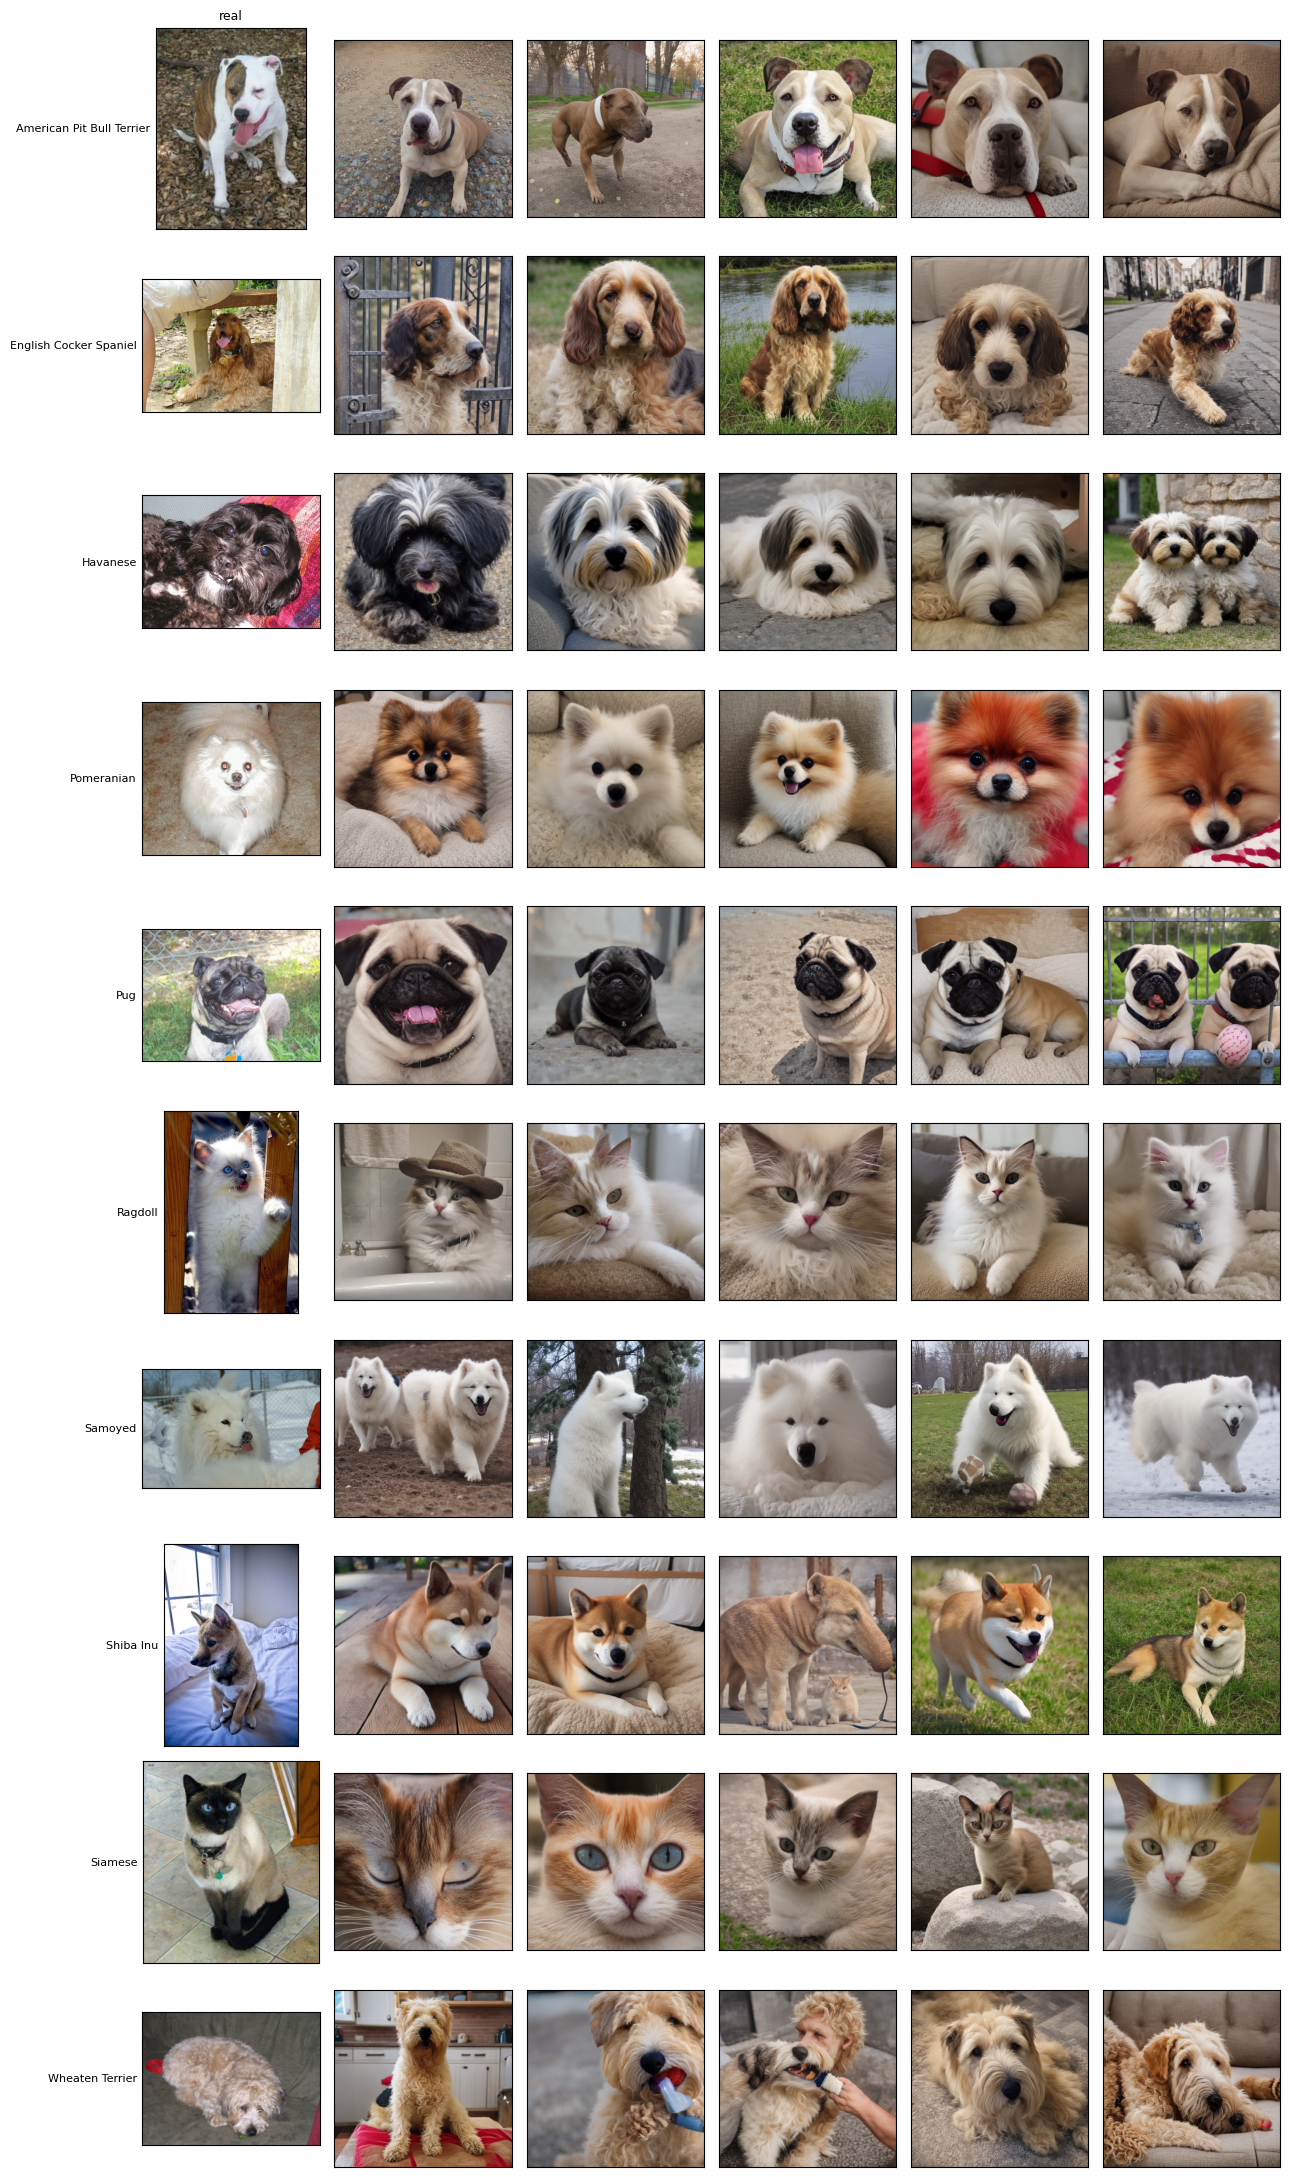

In [ ]:
# first column is a real image, the other five are generated: same breed, same row
rng_preview = random.Random(SEED)
N_PREVIEW = 5

figure, axes = plt.subplots(N_CLASSES, N_PREVIEW + 1, figsize=(13, 22))

for label in range(N_CLASSES):
    real_index = rng_preview.choice(small_by_label[label])
    axes[label, 0].imshow(trainval_raw[real_index][0])
    axes[label, 0].set_ylabel(class_names[label], fontsize=8,
                              rotation=0, ha="right", va="center")

    paths = sorted((SYNTHETIC_DIR / class_names[label]).glob("*.png"))
    for column, path in enumerate(rng_preview.sample(paths, N_PREVIEW), start=1):
        axes[label, column].imshow(plt.imread(path))

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

axes[0, 0].set_title("real", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
CLIP_MODEL = "openai/clip-vit-base-patch32"

clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL).to(DEVICE).eval()

print(f"{'judge model:':<16}{CLIP_MODEL}")

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

judge model:    openai/clip-vit-base-patch32


In [ ]:
@torch.no_grad()
def clip_predict(images, batch_size=64):
    """Zero-shot breed prediction: returns the index of the closest class prompt."""
    prompts = [f"a photo of a {name}, a type of pet" for name in class_names]

    predictions = []
    for start in tqdm(range(0, len(images), batch_size), desc="clip"):
        batch = [images[i][0] for i in range(start, min(start + batch_size, len(images)))]
        inputs = clip_processor(text=prompts, images=batch, return_tensors="pt",
                                padding=True).to(DEVICE)
        logits = clip_model(**inputs).logits_per_image
        predictions.append(logits.argmax(dim=1).cpu())
    return torch.cat(predictions).numpy()

In [ ]:
# CLIP applies its own preprocessing, so the images go in raw
real_judge = Subset(OxfordIIITPet(root="./data", split="trainval",
                                  target_transform=remap_label), small_indices)
synthetic_judge = ImageFolder(SYNTHETIC_DIR)

print(f"{'real:':<14}{len(real_judge):>6}")
print(f"{'synthetic:':<14}{len(synthetic_judge):>6}")

real:            400
synthetic:       595


In [ ]:
clip_real = clip_predict(real_judge)
clip_synthetic = clip_predict(synthetic_judge)

labels_real = np.array([label for _, label in real_judge])
labels_synthetic = np.array(synthetic_judge.targets)

clip:   0%|          | 0/7 [00:00<?, ?it/s]

clip:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
# agreement = share of images where the judge confirms the assigned breed
print(f"{'class':<28}{'real':>8}{'synthetic':>12}{'delta':>9}")
for label, name in enumerate(class_names):
    agreement_real = (clip_real[labels_real == label] == label).mean()
    agreement_synthetic = (clip_synthetic[labels_synthetic == label] == label).mean()
    print(f"{name:<28}{agreement_real:>8.2f}{agreement_synthetic:>12.2f}"
          f"{agreement_synthetic - agreement_real:>+9.2f}")

print(f"\n{'overall:':<28}{(clip_real == labels_real).mean():>8.2f}"
      f"{(clip_synthetic == labels_synthetic).mean():>12.2f}")

class                           real   synthetic    delta
American Pit Bull Terrier       1.00        1.00    +0.00
English Cocker Spaniel          1.00        0.95    -0.05
Havanese                        0.97        0.97    -0.01
Pomeranian                      0.97        1.00    +0.03
Pug                             1.00        1.00    +0.00
Ragdoll                         1.00        1.00    +0.00
Samoyed                         1.00        1.00    +0.00
Shiba Inu                       0.95        1.00    +0.05
Siamese                         0.97        0.88    -0.09
Wheaten Terrier                 0.93        0.97    +0.04

overall:                        0.98        0.98


CLIP agrees with the assigned breed on 98% of both sets, and no class collapses,
so the synthetic labels are not grossly wrong. Siamese is the weakest case at
-0.09, followed by English Cocker Spaniel at -0.05.

The real images are the control group here: at 98% agreement the judge is
reliable on these ten breeds, which is what makes the synthetic column readable.

One caveat on how far this can be pushed. SD-Turbo conditions generation on a
CLIP text encoder, so the images are optimised to sit close to their prompt in
CLIP space, and asking CLIP to score them is partly asking it to confirm its own
criterion. The number says the label is right, not that the breed is faithfully
rendered.

## 10. Generative Augmentation

The 400 real images plus the 595 generated ones: same total and same class
distribution as the ceiling, so the only difference between the two setups is
real versus synthetic.

The synthetic images go through the same evaluation transform as the real ones,
with no random augmentation, to keep this setup separate from the classic one.

In [ ]:
# folder names are the class names, sorted alphabetically: same order as class_names
synthetic_dataset = ImageFolder(SYNTHETIC_DIR, transform=eval_transform)

print(f"{'synthetic images:':<20}{len(synthetic_dataset):>6}")
print(f"{'label order ok:':<20}{synthetic_dataset.classes == class_names!s:>6}")

synthetic images:      595
label order ok:       True


In [ ]:
train_generative = ConcatDataset([train_small, synthetic_dataset])

print(f"{'real:':<12}{len(train_small):>6}")
print(f"{'synthetic:':<12}{len(synthetic_dataset):>6}")
print(f"{'total:':<12}{len(train_generative):>6}")

real:          400
synthetic:     595
total:         995


In [ ]:
runs_generative, predictions_generative, curves_generative = run_setup(
    "generative aug", train_generative, EPOCHS, BATCH_SIZE, LR, test_set, y_true
)
print_runs("4 - generative augmentation (400 real + 595 synthetic)", runs_generative)

generative aug:   0%|          | 0/5 [00:00<?, ?it/s]

--- 4 - generative augmentation (400 real + 595 synthetic) ---
accuracy       0.419  ± 0.035
precision      0.459  ± 0.014
recall         0.419  ± 0.035
f1             0.407  ± 0.040


## 11. Results

Every setup is trained five times, on seeds 0 to 4, and the tables report mean
and standard deviation across those runs.

Single runs turned out not to be comparable: with one run per setup the ranking
changed depending on the seed, so the number of seeds was raised until the
estimates were stable.

Two choices are worth stating before reading the numbers:

- the synthetic set was capped at 595 images to match the ceiling exactly, class
  by class. The pipeline could have produced many more, but that would have
  measured volume instead of the value of a synthetic image against a real one
- accuracy is low in absolute terms because the classifier has no pretrained
  weights. That is deliberate: with ImageNet weights the baseline already reaches
  94.5% and the generative effect disappears

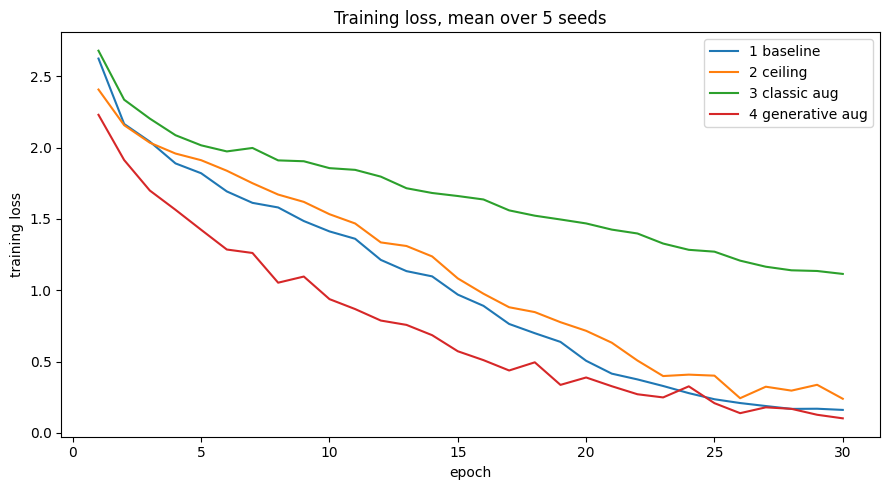

In [ ]:
# training loss per epoch, averaged over the seeds
curves = {
    "1 baseline": curves_baseline,
    "2 ceiling": curves_ceiling,
    "3 classic aug": curves_classic,
    "4 generative aug": curves_generative,
}

figure, axes = plt.subplots(figsize=(9, 5))
for name, seed_curves in curves.items():
    axes.plot(range(1, EPOCHS + 1), np.mean(seed_curves, axis=0), label=name)

axes.set_xlabel("epoch")
axes.set_ylabel("training loss")
axes.set_title("Training loss, mean over 5 seeds")
axes.legend()
plt.tight_layout()
plt.show()

In [ ]:
def accuracies(runs):
    return np.array([run["accuracy"] for run in runs])

def compare(name_a, runs_a, name_b, runs_b):
    """Difference between two setups, expressed in combined standard deviations."""
    a, b = accuracies(runs_a), accuracies(runs_b)
    difference = a.mean() - b.mean()
    spread = np.sqrt(a.std() ** 2 + b.std() ** 2)
    print(f"{name_a} vs {name_b:<22}{difference:>+8.3f}{difference / spread:>8.1f} sd")

In [ ]:
compare("generative", runs_generative, "baseline", runs_baseline)
compare("generative", runs_generative, "ceiling", runs_ceiling)
compare("classic", runs_classic, "baseline", runs_baseline)

generative vs baseline                +0.114     3.2 sd
generative vs ceiling                 +0.010     0.2 sd
classic vs baseline                -0.014    -0.7 sd


Generative augmentation gains 11.4 accuracy points over the baseline, 3.2
combined standard deviations, so the effect is measured rather than assumed. Read
against the ceiling the difference is +1.0 points, 0.2 sd: the two setups are
indistinguishable on these five seeds, which supports equivalence between a
synthetic image and a real one without claiming an advantage.

Classic augmentation sits 0.7 sd below the baseline, and the loss curve shows
why: it is the only setup still above 1.0 after 30 epochs, so it is being cut off
before convergence rather than failing outright.

The loss curves also explain what the accuracy table cannot. Generative
augmentation ends lowest at 0.04, below the ceiling at 0.14 on the same number of
images: synthetic images are more regular and easier to fit, which is consistent
with the limiting factor being the variety of the training data rather than the
capacity of the network.

Per class, the largest gains are Shiba Inu (0.21 to 0.50) and Pug (0.20 to 0.50).
Ragdoll no longer drops. Siamese improves but keeps sending 0.22 of its mass to
Ragdoll in both setups, the same weakness the CLIP check flagged with its -0.09
agreement: the two cat breeds are where both the generator and the classifier
struggle.

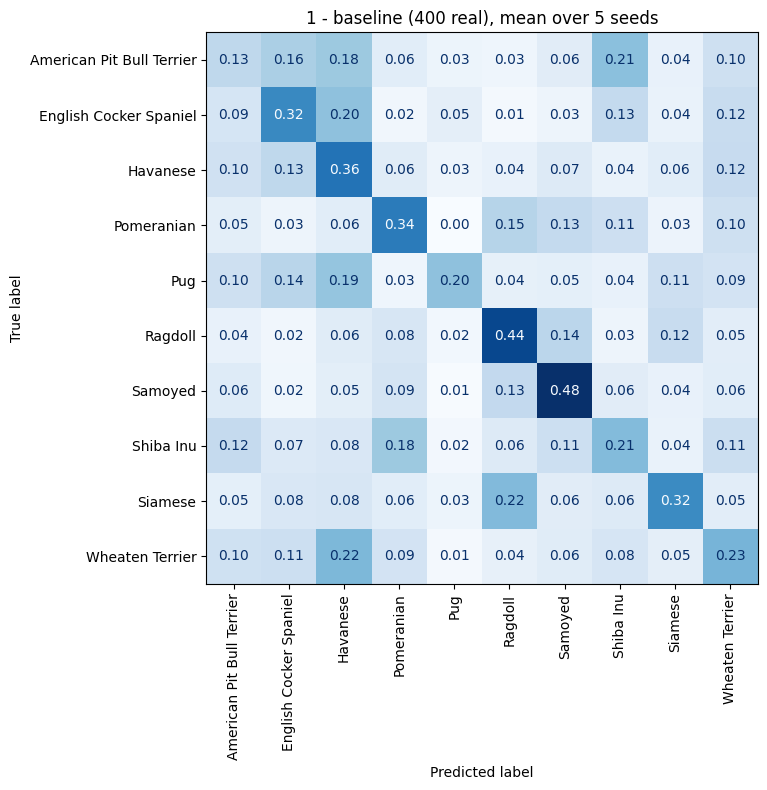

In [ ]:
plot_confusion_matrix(mean_confusion_matrix(predictions_baseline),
                      "1 - baseline (400 real), mean over 5 seeds")

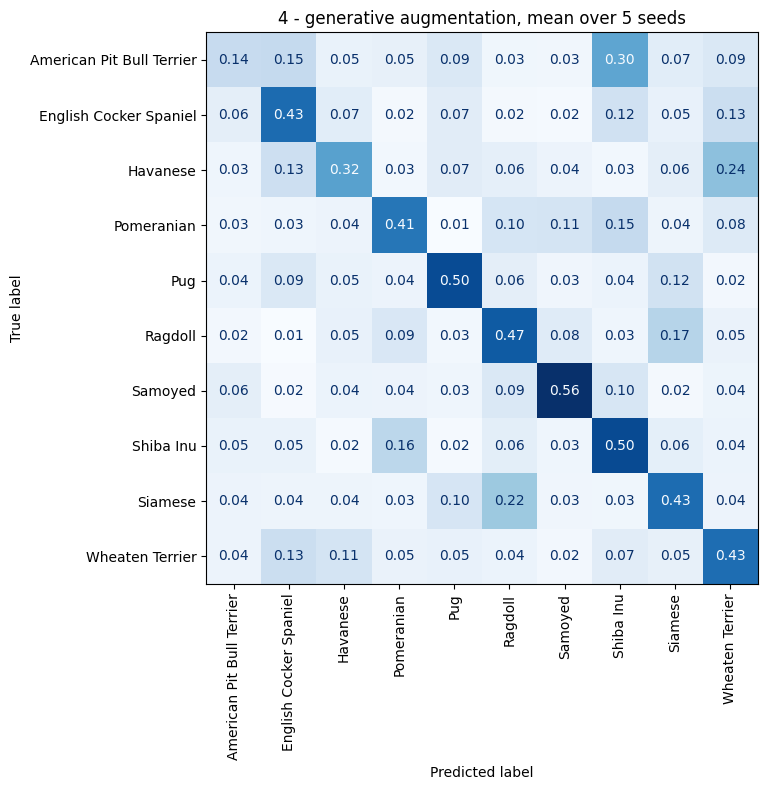

In [ ]:
plot_confusion_matrix(mean_confusion_matrix(predictions_generative),
                      "4 - generative augmentation, mean over 5 seeds")

## 12. FID

Fréchet Inception Distance between the real training images and the generated
ones: it compares the two distributions in Inception feature space instead of
comparing images one by one. Lower is better.

The classification results already tell us the synthetic images are useful. FID
tells us how close they are as a distribution, which is a different question.

In [ ]:
!pip install -q pytorch-ignite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.8/371.8 kB 11.4 MB/s eta 0:00:00


In [ ]:
from ignite.metrics import FID

In [ ]:
real_fid = Subset(OxfordIIITPet(root="./data", split="trainval",
                                transform=raw_transform,
                                target_transform=remap_label), small_indices)
synthetic_fid = ImageFolder(SYNTHETIC_DIR, transform=raw_transform)

print(f"{'real:':<12}{len(real_fid):>6}")
print(f"{'synthetic:':<12}{len(synthetic_fid):>6}")

real:          400
synthetic:     595


In [ ]:
fid_metric = FID(device=DEVICE)

# drop_last: the two datasets have different sizes, so the last batches would not match
real_loader = DataLoader(real_fid, batch_size=32, drop_last=True)
synthetic_loader = DataLoader(synthetic_fid, batch_size=32, drop_last=True)

for (real_images, _), (synthetic_images, _) in tqdm(zip(real_loader, synthetic_loader),
                                                    total=len(real_loader), desc="FID"):
    fid_metric.update((synthetic_images.to(DEVICE), real_images.to(DEVICE)))

print(f"{'FID:':<8}{fid_metric.compute():>8.2f}")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:02<00:00, 48.6MB/s] 


FID:   0%|          | 0/12 [00:00<?, ?it/s]

FID:        0.41


FID 0.41 on 384 images per side. The two distributions are close, which lines up
with the classification results.

Two caveats before reading too much into the number: a reliable FID needs a few
thousand samples per side, and the value produced by pytorch-ignite is not on the
same scale as the FID scores reported in papers. It is useful here as a relative
check, not as an absolute score.

## 13. Pretrained Classifier

The study runs on a classifier trained from scratch, because with ImageNet
weights the baseline is already at 94.5% and no effect is measurable. This
section covers the other regime: does generative augmentation still help when the
backbone already knows these breeds?

Three setups — baseline, classic and generative — with the last block fine-tuned
and fewer epochs, since the model converges quickly.

In [ ]:
def build_pretrained_model(n_classes, seed):
    """ResNet18 with ImageNet weights, only layer4 and the head are trainable."""
    torch.manual_seed(seed)
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    for parameter in model.parameters():
        parameter.requires_grad = False
    for parameter in model.layer4.parameters():
        parameter.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model.to(DEVICE)

In [ ]:
PRETRAINED_EPOCHS = 8
PRETRAINED_LR = 1e-4

def run_pretrained_setup(name, dataset):
    runs = []
    progress = tqdm(SEEDS, desc=name)
    for seed in progress:
        model = build_pretrained_model(N_CLASSES, seed)
        model, _ = train_model(model, dataset, PRETRAINED_EPOCHS, BATCH_SIZE,
                               PRETRAINED_LR, seed, progress)
        torch.save(model.state_dict(),
                   CHECKPOINT_DIR / f"{name.replace(' ', '_')}_seed{seed}.pt")
        _, y_pred = predict(model, test_set)
        runs.append(compute_metrics(y_true, y_pred))
    return runs

In [ ]:
runs_pretrained_baseline = run_pretrained_setup("pretrained baseline", train_small)
print_runs("pretrained baseline (400 real)", runs_pretrained_baseline)

pretrained baseline:   0%|          | 0/5 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth



  0%|          | 0.00/44.7M [00:00<?, ?B/s]
  5%|▌         | 2.25M/44.7M [00:00<00:01, 23.6MB/s]
 11%|█▏        | 5.12M/44.7M [00:00<00:01, 27.4MB/s]
 18%|█▊        | 8.12M/44.7M [00:00<00:01, 29.2MB/s]
 25%|██▍       | 11.0M/44.7M [00:00<00:01, 27.3MB/s]
 34%|███▍      | 15.2M/44.7M [00:00<00:00, 33.2MB/s]
 43%|████▎     | 19.0M/44.7M [00:00<00:00, 34.7MB/s]
 50%|█████     | 22.4M/44.7M [00:00<00:00, 33.2MB/s]
 57%|█████▋    | 25.6M/44.7M [00:00<00:00, 30.5MB/s]
 66%|██████▋   | 29.6M/44.7M [00:00<00:00, 33.4MB/s]
 74%|███████▎  | 32.9M/44.7M [00:01<00:00, 33.0MB/s]
 81%|████████  | 36.1M/44.7M [00:01<00:00, 32.4MB/s]
 90%|████████▉ | 40.0M/44.7M [00:01<00:00, 34.4MB/s]
100%|██████████| 44.7M/44.7M [00:01<00:00, 32.8MB/s]


--- pretrained baseline (400 real) ---
accuracy       0.945  ± 0.002
precision      0.947  ± 0.002
recall         0.945  ± 0.002
f1             0.945  ± 0.002


In [ ]:
runs_pretrained_generative = run_pretrained_setup("pretrained generative", train_generative)
print_runs("pretrained generative (400 real + 595 synthetic)", runs_pretrained_generative)

pretrained generative:   0%|          | 0/5 [00:00<?, ?it/s]

--- pretrained generative (400 real + 595 synthetic) ---
accuracy       0.944  ± 0.004
precision      0.946  ± 0.004
recall         0.944  ± 0.004
f1             0.944  ± 0.003


In [ ]:
runs_pretrained_classic = run_pretrained_setup("pretrained classic", train_small_augmented)
print_runs("pretrained classic augmentation (400 real)", runs_pretrained_classic)

pretrained classic:   0%|          | 0/5 [00:00<?, ?it/s]

--- pretrained classic augmentation (400 real) ---
accuracy       0.953  ± 0.002
precision      0.954  ± 0.002
recall         0.953  ± 0.002
f1             0.953  ± 0.002


The picture changes. With ImageNet weights the baseline is already at 94.5%, and
from there:

- classic augmentation gains 0.8 points, several standard deviations wide at this
  variance
- generative augmentation loses 0.1 points, well inside the noise: the 595
  synthetic images neither help nor hurt

What still pays off is classic augmentation, which does not add images but adds
variation to the ones already there. That the generative effect vanishes is a
statement about this dataset rather than about the method: ImageNet covers cats
and dogs well, and a target domain it does not cover would put the model back in
the regime where generative augmentation was worth 11 points.

Standard deviation drops from 0.010 to 0.002 as well: transfer learning makes the
training stable, which is another way of saying the pretrained features are doing
almost all the work.

## 14. Degraded Test Set

The use case is an industrial surveillance system, where frames are rarely as
clean as the ones in OxfordIIITPet: out-of-focus optics, motion and cheap sensors
all remove high frequency detail.

Every setup is re-evaluated on the same test set blurred at two intensities, with
no retraining: the checkpoints saved during training are reloaded and scored
again. What matters is not that accuracy drops, which it will, but whether the
setups lose ground at the same rate — in particular whether the models trained on
synthetic images hold up as well as the ones trained on real data.

In [ ]:
# gaussian blur at two intensities: the degradation typical of surveillance footage
BLUR_LEVELS = {"light": 3, "strong": 9}

degraded_sets = {}
for name, kernel in BLUR_LEVELS.items():
    blur_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.GaussianBlur(kernel_size=kernel),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    blurred = OxfordIIITPet(root="./data", split="test",
                            transform=blur_transform, target_transform=remap_label)
    degraded_sets[name] = Subset(blurred, test_indices)

print(f"{'levels:':<12}{list(degraded_sets):}")
print(f"{'test size:':<12}{len(degraded_sets['light']):>6}")

levels:     ['light', 'strong']
test size:    1000


In [ ]:
def evaluate_checkpoints(name, build, dataset):
    """Reload every seed of a setup and score it on the given test set."""
    accuracies = []
    for seed in SEEDS:
        model = build(N_CLASSES, seed)
        state = torch.load(CHECKPOINT_DIR / f"{name.replace(' ', '_')}_seed{seed}.pt")
        model.load_state_dict(state)
        _, y_pred = predict(model, dataset)
        accuracies.append(accuracy_score(y_true, y_pred))
    return np.array(accuracies)

In [ ]:
setups = [
    ("baseline", build_model),
    ("ceiling", build_model),
    ("classic aug", build_model),
    ("generative aug", build_model),
    ("pretrained baseline", build_pretrained_model),
    ("pretrained classic", build_pretrained_model),
    ("pretrained generative", build_pretrained_model),
]

header = f"{'setup':<24}{'clean':>14}{'light blur':>14}{'strong blur':>14}"
print(header)
print("-" * len(header))

for name, build in setups:
    row = f"{name:<24}"
    for dataset in [test_set, degraded_sets["light"], degraded_sets["strong"]]:
        values = evaluate_checkpoints(name, build, dataset)
        row += f"{values.mean():>9.3f} ±{values.std():>4.3f}"
    print(row)

setup                            clean    light blur   strong blur
------------------------------------------------------------------
baseline                    0.304 ±0.010    0.291 ±0.009    0.276 ±0.006
ceiling                     0.409 ±0.018    0.395 ±0.019    0.355 ±0.019
classic aug                 0.290 ±0.016    0.280 ±0.016    0.244 ±0.016
generative aug              0.419 ±0.035    0.414 ±0.037    0.383 ±0.038
pretrained baseline         0.945 ±0.002    0.928 ±0.006    0.898 ±0.010
pretrained classic          0.953 ±0.002    0.939 ±0.006    0.917 ±0.006
pretrained generative       0.944 ±0.004    0.924 ±0.006    0.889 ±0.008


Accuracy drops everywhere, as expected, but not at the same rate. Trained from
scratch, generative augmentation loses 3.6 points from clean to strong blur
against 5.4 for the ceiling, so the gap between them widens from +1.0 to +2.8
points. The two were indistinguishable on clean images; under degradation the
synthetic setup holds slightly better.

A plausible reading: SD-Turbo at one step produces images with little fine
detail, so the classifier cannot rely on high frequency cues — which is exactly
what blur removes. It is the same mechanism that makes occlusion a useful
augmentation.

The trend is consistent but not measured: the standard deviations on the
generative setup are around 0.037, so the difference against the ceiling stays
within one deviation at every blur level.

With a pretrained backbone the order reverses, and generative is the most fragile
of the three at -5.5 points against -3.6 for classic. Geometric and colour
transforms teach invariance; extra images of already known classes do not.

## 15. Conclusions

- **Generative augmentation works, and the effect is measured.** 41.9% ±0.035
against 30.4% ±0.010 for the baseline: 11.4 points, 3.2 combined standard
deviations.

- **A synthetic image is worth about as much as a real one here.** Against the
ceiling the difference is +1.0 points, 0.2 sd, on the same 995 images and the
same class distribution. That supports equivalence; it does not show an
advantage, and five seeds are not enough to claim one either way.

- **Classic augmentation lands 0.7 sd below the baseline**, and the loss curve
shows it is still above 1.0 after 30 epochs. It is being cut off before
convergence rather than failing outright.

- **The two cat breeds are the weak point of the whole pipeline.** CLIP scores
Siamese lowest among the synthetic images at -0.09, and the classifier keeps
sending 0.22 of Siamese onto Ragdoll in every setup. The largest gains are
elsewhere: Shiba Inu 0.21 to 0.50, Pug 0.20 to 0.50.

- **The effect disappears with a pretrained backbone.** 94.4% against 94.5%,
inside the noise. What decides is not the technique but how much the model
already knows about the target classes — which is why the from-scratch regime is
the one that matters for a domain ImageNet does not cover.

- **Under blur the synthetic setup does not degrade faster**, contrary to what
one might expect from images that are cleaner and more regular than real ones.
The trend favours it slightly, within one standard deviation.

- **Next step.** The synthetic set was capped at 595 to match the ceiling, so
what was measured is the value of a synthetic image, not the effect of adding
more data. Generating many more is untested: the advantage may keep growing, or
the model may start learning SD-Turbo's artefacts instead of the breeds.